In [11]:
import yfinance as yf
import pandas as pd
import os

# Define stocks (Indian market - NSE)
tickers = {
    "TCS":        "TCS.NS",
    "Infosys":    "INFY.NS",
    "Reliance":   "RELIANCE.NS",
    "HDFC Bank":  "HDFCBANK.NS",
    "ITC":        "ITC.NS"
}

# Download 5 years of data
raw = yf.download(
    list(tickers.values()),
    start="2020-01-01",
    end="2024-12-31",
    auto_adjust=True
)

# Extract closing prices
close_df = raw["Close"]
close_df.columns = list(tickers.keys())

# Save to CSV
close_df.to_csv(r"C:/Users/DEEPTY GUPTA/stock-market-analysis/data/stock_prices.csv", 
                index_label="Date")
print("✅ Data downloaded successfully!")
print(close_df.tail())

[*********************100%***********************]  5 of 5 completed

✅ Data downloaded successfully!
                   TCS      Infosys    Reliance    HDFC Bank          ITC
2024-12-23  888.490295  1868.988525  432.371521  1217.437744  3893.971436
2024-12-24  887.059631  1854.176880  436.200623  1217.885864  3913.823975
2024-12-26  883.433655  1852.574341  434.833069  1211.710571  3904.085205
2024-12-27  887.133667  1861.655518  436.337372  1216.192749  3900.105469
2024-12-30  877.094360  1851.214478  434.878662  1205.883789  3894.439453


In [12]:
nifty = yf.download("^NSEI", start="2020-01-01", end="2024-12-31", auto_adjust=True)
nifty_close = nifty["Close"]
nifty_close.to_csv("../data/nifty50.csv")
print("✅ NIFTY 50 downloaded!")

[*********************100%***********************]  1 of 1 completed

✅ NIFTY 50 downloaded!


In [15]:
import pandas as pd

# Load using column POSITION (0 = first column) instead of name
df = pd.read_csv(r"C:\Users\DEEPTY GUPTA\stock-market-analysis\data\stock_prices.csv", 
                 index_col=0)   # ← 0 means first column

# Rename index to Date
df.index.name = "Date"

# Convert index to datetime
df.index = pd.to_datetime(df.index)

print("✅ Loaded successfully!")
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nFirst 3 rows:\n", df.head(3))

✅ Loaded successfully!
Shape: (1237, 5)

Missing Values:
 TCS          0
Infosys      0
Reliance     0
HDFC Bank    0
ITC          0
dtype: int64

Data Types:
 TCS          float64
Infosys      float64
Reliance     float64
HDFC Bank    float64
ITC          float64
dtype: object

First 3 rows:
                    TCS     Infosys    Reliance   HDFC Bank          ITC
Date                                                                   
2020-01-01  605.529358  633.151062  173.395218  675.324219  1841.149780
2020-01-02  609.389099  631.303711  174.669647  686.821228  1832.698486
2020-01-03  600.698853  641.013489  173.686508  687.648804  1869.222168


In [9]:
import pandas as pd

# First, peek at the raw file WITHOUT any index settings
df_raw = pd.read_csv(r"C:\Users\DEEPTY GUPTA\stock-market-analysis\data\stock_prices.csv")

# See exactly what columns exist
print("Columns:", df_raw.columns.tolist())
print("\nFirst 3 rows:")
print(df_raw.head(3))


Columns: ['Unnamed: 0', 'TCS', 'Infosys', 'Reliance', 'HDFC Bank', 'ITC']

First 3 rows:
   Unnamed: 0         TCS     Infosys    Reliance   HDFC Bank          ITC
0  2020-01-01  605.529358  633.151062  173.395218  675.324219  1841.149780
1  2020-01-02  609.389099  631.303711  174.669647  686.821228  1832.698486
2  2020-01-03  600.698853  641.013489  173.686508  687.648804  1869.222168


In [16]:
# Fill missing values (market holidays cause gaps)
df = df.fillna(method="ffill")  # forward fill

# Confirm no nulls remain
print("Nulls after cleaning:", df.isnull().sum().sum())

# Save cleaned data
df.to_csv("../data/stock_prices_clean.csv")
print("✅ Cleaned data saved!")

Nulls after cleaning: 0
✅ Cleaned data saved!


C:\Users\DEEPTY GUPTA\AppData\Local\Temp\ipykernel_31472\545324603.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")  # forward fill


Matplotlib is building the font cache; this may take a moment.


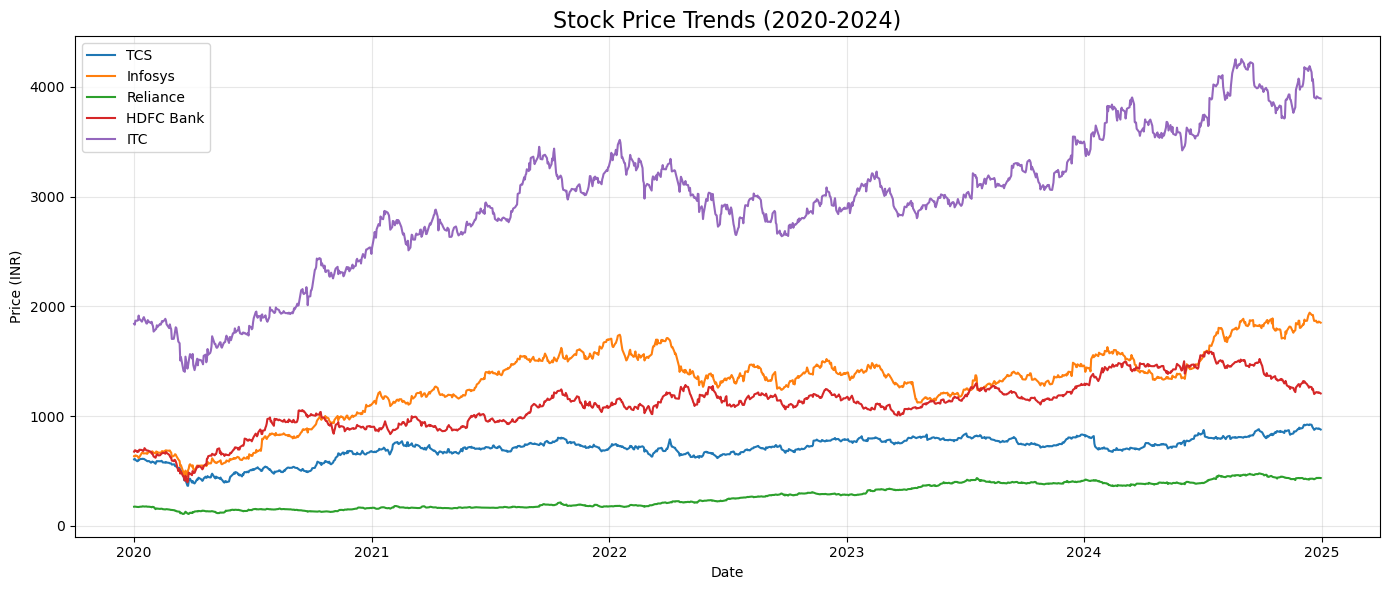

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
for col in df.columns:
    plt.plot(df.index, df[col], label=col)

plt.title("Stock Price Trends (2020-2024)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/price_trends.png", dpi=150)
plt.show()

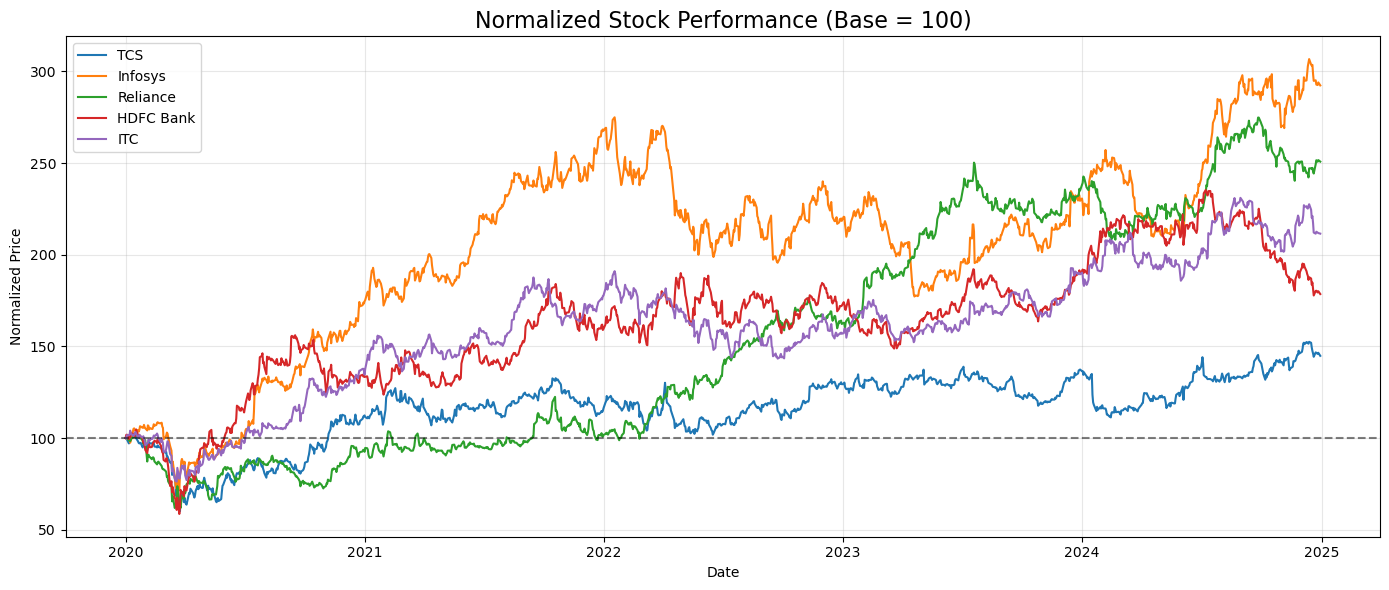

In [18]:
# Normalize to 100 at start (shows % growth from base)
normalized = (df / df.iloc[0]) * 100

plt.figure(figsize=(14, 6))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)

plt.title("Normalized Stock Performance (Base = 100)", fontsize=16)
plt.axhline(y=100, color='black', linestyle='--', alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/normalized_performance.png", dpi=150)
plt.show()

📊 Annualized Volatility (%):
 TCS          27.27
Infosys      27.86
Reliance     25.88
HDFC Bank    29.74
ITC          24.47
dtype: float64


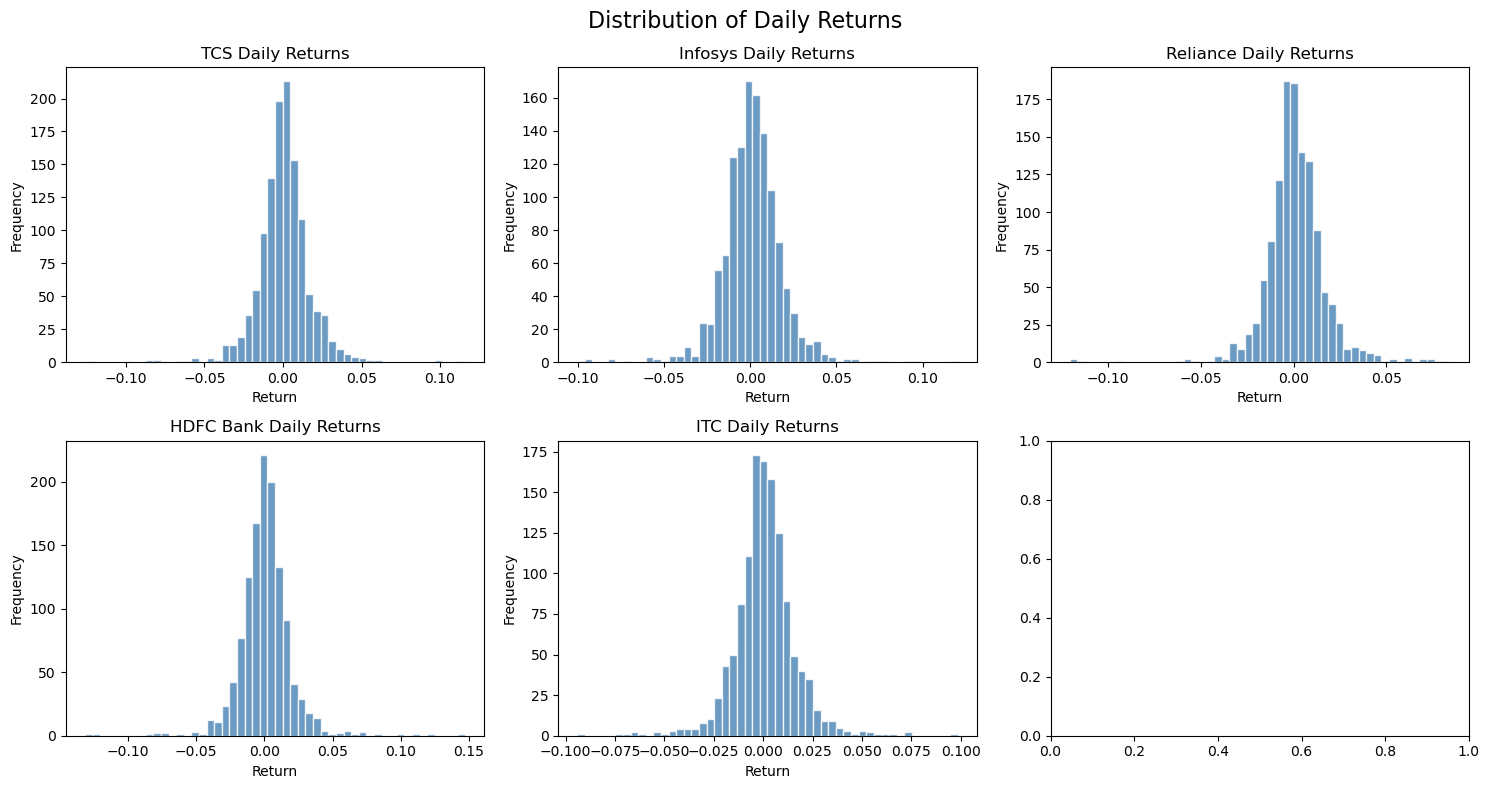

In [19]:
import seaborn as sns

# Calculate daily returns
returns = df.pct_change().dropna()
returns.to_csv("../data/daily_returns.csv")

# Annualized volatility
volatility = returns.std() * (252 ** 0.5) * 100
print("📊 Annualized Volatility (%):\n", volatility.round(2))

# Distribution of returns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(returns.columns):
    axes[i].hist(returns[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f"{col} Daily Returns")
    axes[i].set_xlabel("Return")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Distribution of Daily Returns", fontsize=16)
plt.tight_layout()
plt.savefig("../data/return_distribution.png", dpi=150)
plt.show()

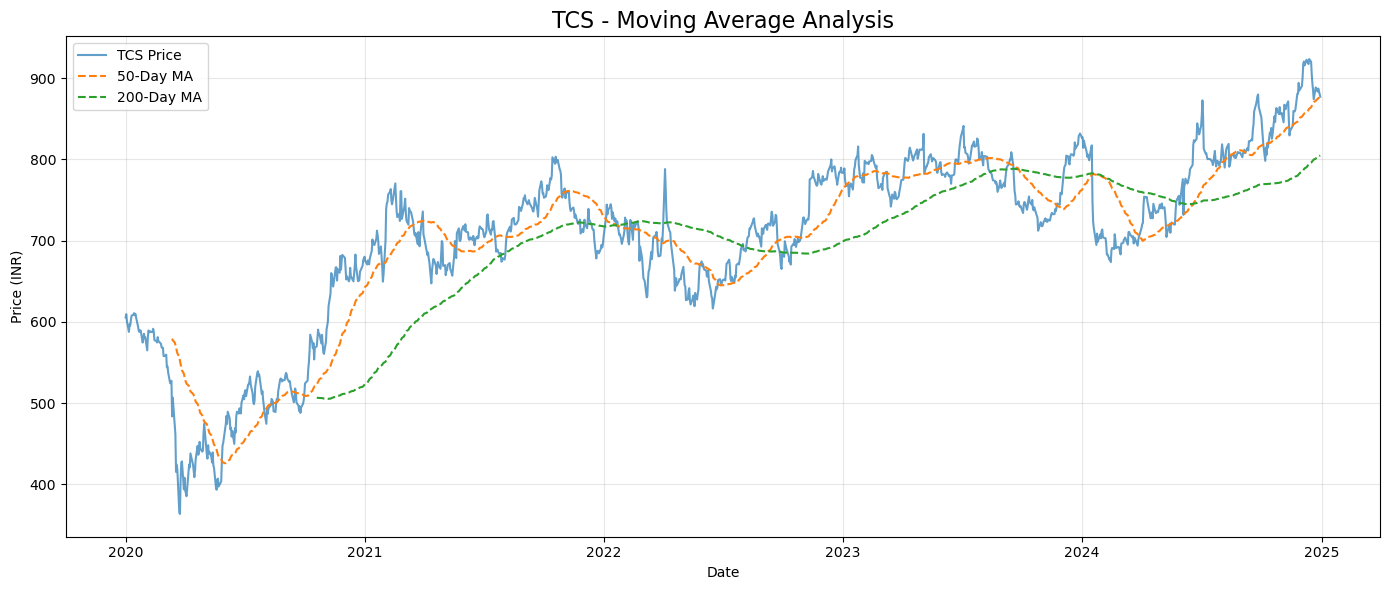

In [20]:
# Focus on TCS as example
tcs = df["TCS"].copy().to_frame()
tcs["MA_50"]  = tcs["TCS"].rolling(window=50).mean()
tcs["MA_200"] = tcs["TCS"].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(tcs["TCS"],    label="TCS Price",    alpha=0.7)
plt.plot(tcs["MA_50"],  label="50-Day MA",    linestyle="--")
plt.plot(tcs["MA_200"], label="200-Day MA",   linestyle="--")

plt.title("TCS - Moving Average Analysis", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/tcs_moving_avg.png", dpi=150)
plt.show()

C:\Users\DEEPTY GUPTA\AppData\Local\Temp\ipykernel_31472\3352296935.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  annual_returns = df.groupby("Year").apply(


📈 Annual Returns (%):
         TCS  Infosys  Reliance  HDFC Bank    ITC
Year                                            
2020  12.33    74.60     -7.53      33.30  34.60
2021   4.26    52.73      7.50      19.57  29.06
2022   8.39   -18.84     58.74       6.31 -13.52
2023   6.15     3.93     44.28       9.11  20.46
2024   6.13    26.75      5.37      -6.20  11.21


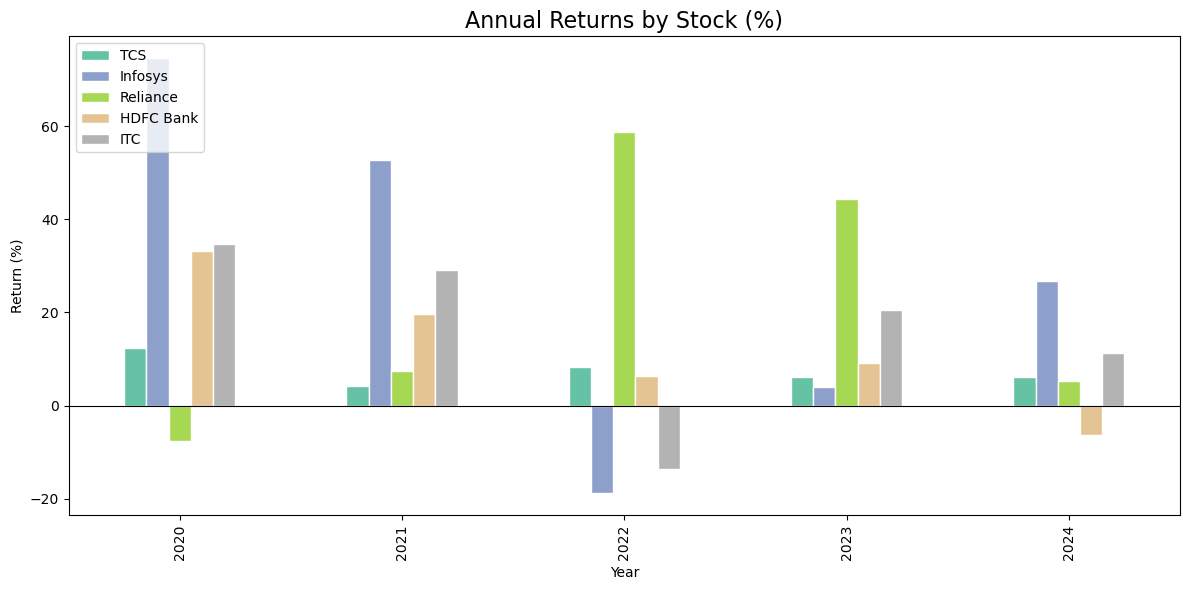

In [21]:
# Calculate yearly returns
df["Year"] = df.index.year
annual_returns = df.groupby("Year").apply(
    lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100
).drop(columns="Year").round(2)

print("📈 Annual Returns (%):\n", annual_returns)
annual_returns.to_csv("../data/annual_returns.csv")

# Bar chart
annual_returns.plot(kind="bar", figsize=(12, 6), colormap="Set2", edgecolor="white")
plt.title("Annual Returns by Stock (%)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Return (%)")
plt.axhline(y=0, color="black", linewidth=0.8)
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../data/annual_returns.png", dpi=150)
plt.show()

In [22]:
import sqlite3

conn = sqlite3.connect("../data/stocks.db")

# Load clean price data
df_sql = pd.read_csv("../data/stock_prices_clean.csv", index_col="Date", parse_dates=True)
df_sql_long = df_sql.reset_index().melt(id_vars="Date", var_name="ticker", value_name="close_price")
df_sql_long["year"]  = pd.to_datetime(df_sql_long["Date"]).dt.year
df_sql_long["month"] = pd.to_datetime(df_sql_long["Date"]).dt.month

df_sql_long.to_sql("stock_prices", conn, if_exists="replace", index=False)
print("✅ Data loaded into SQLite!")

✅ Data loaded into SQLite!


In [23]:
# Query 1: Average price per stock per year
q1 = pd.read_sql_query("""
    SELECT ticker, year,
           ROUND(AVG(close_price), 2) AS avg_price,
           ROUND(MAX(close_price), 2) AS max_price,
           ROUND(MIN(close_price), 2) AS min_price
    FROM stock_prices
    GROUP BY ticker, year
    ORDER BY ticker, year
""", conn)
print("📊 Avg Price Per Year:\n", q1)
q1.to_csv("../data/sql_avg_price.csv", index=False)

# Query 2: Best performing stock each year
q2 = pd.read_sql_query("""
    SELECT year, ticker, ROUND(avg_price, 2) as avg_price
    FROM (
        SELECT year, ticker, AVG(close_price) as avg_price,
               RANK() OVER (PARTITION BY year ORDER BY AVG(close_price) DESC) as rnk
        FROM stock_prices
        GROUP BY year, ticker
    )
    WHERE rnk = 1
""", conn)
print("\n🏆 Best Stock Each Year:\n", q2)

# Query 3: Monthly average (for Power BI)
q3 = pd.read_sql_query("""
    SELECT ticker, year, month,
           ROUND(AVG(close_price), 2) AS avg_monthly_price
    FROM stock_prices
    GROUP BY ticker, year, month
    ORDER BY ticker, year, month
""", conn)
q3.to_csv("../data/sql_monthly_avg.csv", index=False)
print("✅ SQL analysis complete!")

conn.close()

📊 Avg Price Per Year:
        ticker  year  avg_price  max_price  min_price
0   HDFC Bank  2020     787.88    1054.02     395.48
1   HDFC Bank  2021     999.51    1243.02     835.20
2   HDFC Bank  2022    1152.05    1283.07    1017.18
3   HDFC Bank  2023    1153.91    1297.30    1004.86
4   HDFC Bank  2024    1415.25    1589.14    1200.51
5         ITC  2020    1945.85    2536.84    1403.24
6         ITC  2021    2922.30    3454.15    2510.28
7         ITC  2022    2994.83    3517.31    2638.85
8         ITC  2023    3091.89    3547.73    2803.40
9         ITC  2024    3808.68    4253.91    3369.29
10    Infosys  2020     757.08    1105.51     452.36
11    Infosys  2021    1363.88    1699.22    1090.76
12    Infosys  2022    1441.14    1741.10    1238.75
13    Infosys  2023    1312.58    1486.04    1122.01
14    Infosys  2024    1628.95    1942.22    1328.67
15   Reliance  2020     143.34     177.15     107.23
16   Reliance  2021     172.24     212.36     154.59
17   Reliance  2022    

In [24]:
# Run this to confirm all files exist
import os
path = r"C:\Users\DEEPTY GUPTA\stock-market-analysis\data"
for f in os.listdir(path):
    print("✅", f)

✅ annual_returns.csv
✅ annual_returns.png
✅ daily_returns.csv
✅ nifty50.csv
✅ normalized_performance.png
✅ price_trends.png
✅ return_distribution.png
✅ sql_avg_price.csv
✅ sql_monthly_avg.csv
✅ stocks.db
✅ stock_prices.csv
✅ stock_prices_clean.csv
✅ tcs_moving_avg.png


In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\DEEPTY GUPTA\stock-market-analysis\data\stock_prices_clean.csv", index_col=0)
df.index = pd.to_datetime(df.index)

returns = df.pct_change().dropna()
volatility = returns.std() * (252 ** 0.5) * 100
total_return = ((df.iloc[-1] / df.iloc[0]) - 1) * 100

risk_return = pd.DataFrame({
    "Stock": volatility.index,
    "Volatility": volatility.values.round(2),
    "Total_Return": total_return.values.round(2)
})

risk_return.to_csv(
    r"C:\Users\DEEPTY GUPTA\stock-market-analysis\data\risk_return.csv",
    index=False)

print("✅ Done!")
print(risk_return)

✅ Done!
       Stock  Volatility  Total_Return
0        TCS       27.27         44.85
1    Infosys       27.86        192.38
2   Reliance       25.88        150.80
3  HDFC Bank       29.74         78.56
4        ITC       24.47        111.52


In [1]:
# Get all real values for dashboard
print("=== REAL VALUES FOR DASHBOARD ===")
print(f"Best Return Stock: {total_return.idxmax()} — {total_return.max():.2f}%")
print(f"Lowest Risk Stock: {volatility.idxmin()} — {volatility.min():.2f}%")
print(f"Average Annual Return: {annual_returns.mean().mean():.2f}%")
print(f"Annual Returns:\n{annual_returns}")

=== REAL VALUES FOR DASHBOARD ===


NameError: name 'total_return' is not defined

In [2]:
import pandas as pd
import numpy as np

# Load clean data
df = pd.read_csv(r"C:\Users\DEEPTY GUPTA\stock-market-analysis\data\stock_prices_clean.csv", index_col=0)
df.index = pd.to_datetime(df.index)

# Daily returns
returns = df.pct_change().dropna()

# Volatility
volatility = returns.std() * (252 ** 0.5) * 100

# Total return
total_return = ((df.iloc[-1] / df.iloc[0]) - 1) * 100

# Annual returns
df['Year'] = df.index.year
annual_returns = df.groupby('Year').apply(
    lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100
).drop(columns='Year').round(2)

# Portfolio stats
portfolio = returns.mean(axis=1)
cumulative = (1 + portfolio).cumprod() * 100
ann_port_return = ((cumulative.iloc[-1]/100) ** (1/5) - 1) * 100
ann_port_vol = portfolio.std() * np.sqrt(252) * 100
sharpe = (ann_port_return - 6) / ann_port_vol
equal_wt_total = cumulative.iloc[-1] - 100

# Correlation
corr = returns.corr().round(2)

print("=" * 50)
print("REAL VALUES FOR DASHBOARD")
print("=" * 50)
print(f"\n✅ Best Return Stock: {total_return.idxmax()} — {total_return.max():.2f}%")
print(f"✅ Lowest Risk Stock: {volatility.idxmin()} — {volatility.min():.2f}%")
print(f"✅ Equal Weight Portfolio Total Return: {equal_wt_total:.2f}%")
print(f"✅ Average Annual Return: {annual_returns.mean().mean():.2f}%")
print(f"✅ Annualized Portfolio Return: {ann_port_return:.2f}%")
print(f"✅ Annualized Portfolio Volatility: {ann_port_vol:.2f}%")
print(f"✅ Sharpe Ratio: {sharpe:.2f}")

print("\n📊 TOTAL RETURNS PER STOCK:")
for stock, val in total_return.items():
    print(f"   {stock}: {val:.2f}%")

print("\n📊 VOLATILITY PER STOCK:")
for stock, val in volatility.items():
    print(f"   {stock}: {val:.2f}%")

print("\n📊 ANNUAL RETURNS:")
print(annual_returns.to_string())

print("\n📊 CORRELATION MATRIX:")

REAL VALUES FOR DASHBOARD

✅ Best Return Stock: Infosys — 192.38%
✅ Lowest Risk Stock: ITC — 24.47%
✅ Equal Weight Portfolio Total Return: 129.20%
✅ Average Annual Return: 17.15%
✅ Annualized Portfolio Return: 18.04%
✅ Annualized Portfolio Volatility: 19.00%
✅ Sharpe Ratio: 0.63

📊 TOTAL RETURNS PER STOCK:
   TCS: 44.85%
   Infosys: 192.38%
   Reliance: 150.80%
   HDFC Bank: 78.56%
   ITC: 111.52%

📊 VOLATILITY PER STOCK:
   TCS: 27.27%
   Infosys: 27.86%
   Reliance: 25.88%
   HDFC Bank: 29.74%
   ITC: 24.47%

📊 ANNUAL RETURNS:
        TCS  Infosys  Reliance  HDFC Bank    ITC
Year                                            
2020  12.33    74.60     -7.53      33.30  34.60
2021   4.26    52.73      7.50      19.57  29.06
2022   8.39   -18.84     58.74       6.31 -13.52
2023   6.15     3.93     44.28       9.11  20.46
2024   6.13    26.75      5.37      -6.20  11.21

📊 CORRELATION MATRIX:


C:\Users\DEEPTY GUPTA\AppData\Local\Temp\ipykernel_20868\3872851141.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  annual_returns = df.groupby('Year').apply(
